In [28]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import SparsePauliOp, Statevector

In [29]:
pauli_terms = [
    ("ZI",  0.50),
    ("IZ", -0.70),
    ("XX",  0.30),
]

H = SparsePauliOp.from_list(pauli_terms)

alpha = sum(abs(coeff) for _, coeff in pauli_terms)

print("Hamiltonian:")
print(H)

print("\nNormalization alpha =", alpha)
print("\nNormalized Hamiltonian H/alpha:")
print(H / alpha)

Hamiltonian:
SparsePauliOp(['ZI', 'IZ', 'XX'],
              coeffs=[ 0.5+0.j, -0.7+0.j,  0.3+0.j])

Normalization alpha = 1.5

Normalized Hamiltonian H/alpha:
SparsePauliOp(['ZI', 'IZ', 'XX'],
              coeffs=[ 0.33333333+0.j, -0.46666667+0.j,  0.2       +0.j])


In [30]:
theta_candidates = [
    [0.12, 0.73, 0.41, 0.88],
    [0.65, 0.19, 0.94, 0.37],
    [0.08, 0.56, 0.31, 0.79],
    [0.44, 0.22, 0.68, 0.15]]

num_candidates = 4
num_candidate_qubits = 2
num_system_qubits = 2

for k, theta_k in enumerate(theta_candidates):
    print(f"Candidate {k}: {theta_k}")

Candidate 0: [0.12, 0.73, 0.41, 0.88]
Candidate 1: [0.65, 0.19, 0.94, 0.37]
Candidate 2: [0.08, 0.56, 0.31, 0.79]
Candidate 3: [0.44, 0.22, 0.68, 0.15]



We use a candidate-index register to identify the different parameter
configurations coherently.

For \(N=4\) candidates, two qubits are sufficient because

$$
n_{\mathrm{candidate}}
=
\log_2 N
=
2.
$$

Applying a Hadamard gate to each candidate qubit prepares

$$
|00\rangle
\longmapsto
\frac{1}{2}
\left(
|00\rangle
+
|01\rangle
+
|10\rangle
+
|11\rangle
\right).
$$

Equivalently,

$$
|\chi\rangle
=
\frac{1}{\sqrt N}
\sum_{k=0}^{N-1}|k\rangle.
$$

Each basis state \(|k\rangle\) identifies one parameter configuration
\(\boldsymbol{\theta}_k\). The candidate register must remain coherent
throughout the probability-oracle and phase-oracle construction.

In [31]:
# Create the register used to label the candidate configurations.
# For four candidates, two qubits represent:
# |00> -> candidate 0
# |01> -> candidate 1
# |10> -> candidate 2
# |11> -> candidate 3

candidate_register = QuantumRegister(
    num_candidate_qubits,
    name="candidate"
)
# Create a circuit containing only the candidate-index register.
candidate_superposition = QuantumCircuit(
    candidate_register,
    name="CandidateSuperposition"
)
# Applying H to every candidate qubit prepares
#       1/sqrt(N) * sum_k |k>
# For N = 4, this is:
#       1/2 (|00> + |01> + |10> + |11>)
candidate_superposition.h(candidate_register)

print("Candidate-register superposition circuit:")
print(candidate_superposition.draw())

Candidate-register superposition circuit:
             ┌───┐
candidate_0: ┤ H ├
             ├───┤
candidate_1: ┤ H ├
             └───┘


In [32]:
# Simulate the candidate register to verify that all four
# candidate indices have equal amplitudes.
candidate_statevector = Statevector.from_instruction(
    candidate_superposition
)

print("\nCandidate-register statevector:")
print(candidate_statevector)

print("\nCandidate probabilities:")
print(candidate_statevector.probabilities_dict())


Candidate-register statevector:
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))

Candidate probabilities:
{np.str_('00'): np.float64(0.2499999999999999), np.str_('01'): np.float64(0.2499999999999999), np.str_('10'): np.float64(0.2499999999999999), np.str_('11'): np.float64(0.2499999999999999)}



The candidate register is initially prepared in

$$\frac{1}{\sqrt{N}}
\sum_{k=0}^{N-1}|k\rangle.
$$

For every candidate index \(k\), we associate the parameter configuration
\(\boldsymbol{\theta}_k\) with a working state


$$|\psi_k\rangle
=
U(\boldsymbol{\theta}_k)|0\rangle_{\mathrm{sys}}.
$$

The coherent loading operation is


$$U_{\mathrm{load}}
=
\sum_{k=0}^{N-1}
|k\rangle\langle k|
\otimes
U(\boldsymbol{\theta}_k).
$$

Therefore,


$$U_{\mathrm{load}}
\left(
\frac{1}{\sqrt{N}}
\sum_{k=0}^{N-1}
|k\rangle|0\rangle_{\mathrm{sys}}
\right)
=
\frac{1}{\sqrt{N}}
\sum_{k=0}^{N-1}
|k\rangle|\psi_k\rangle.
$$

No physical interpretation is assigned to the parameter values here.
They simply define a different working state for every coherent candidate branch.

In [33]:
# ============================================================
# Step 5: Build the coherent candidate-dependent state loader
# ============================================================

def build_candidate_unitary(theta):
    """
    Construct a generic two-qubit unitary U(theta).

    The four input values are used only to produce a distinct working
    state for each candidate. No application-specific interpretation
    is assigned to them in this proof of concept.

    Parameters
    ----------
    theta : sequence of float
        Four numerical parameters associated with one candidate.

    Returns
    -------
    QuantumCircuit
        A two-qubit unitary U(theta).
    """
    if len(theta) != 4:
        raise ValueError(
            f"Expected four parameters, but received {len(theta)}."
        )

    circuit = QuantumCircuit(num_system_qubits)

    # First parameter-dependent rotation layer.
    circuit.ry(theta[0], 0)
    circuit.ry(theta[1], 1)

    # Introduce interaction between the two system qubits.
    circuit.cx(0, 1)

    # Second parameter-dependent rotation layer.
    circuit.ry(theta[2], 0)
    circuit.ry(theta[3], 1)

    return circuit


# Candidate-index register:
#
#   |00> -> candidate 0
#   |01> -> candidate 1
#   |10> -> candidate 2
#   |11> -> candidate 3
candidate_register = QuantumRegister(
    num_candidate_qubits,
    name="candidate"
)

# System register on which the problem Hamiltonian H will act.
system_register = QuantumRegister(
    num_system_qubits,
    name="system"
)

# Combined circuit for coherent candidate-state preparation.
coherent_state_loader = QuantumCircuit(
    candidate_register,
    system_register,
    name="U_load"
)

# Prepare the uniform candidate superposition:
#
#       1/sqrt(N) sum_k |k>
coherent_state_loader.h(candidate_register)

# Apply U(theta_k) to the system register only when the candidate
# register contains the corresponding basis state |k>.
#
# Together, these controlled operations implement:
#
#   U_load = sum_k |k><k| tensor U(theta_k)
for k, theta_k in enumerate(theta_candidates):

    # Construct U(theta_k) for candidate k.
    candidate_unitary = build_candidate_unitary(theta_k)

    # Convert the candidate circuit into a reusable gate.
    candidate_gate = candidate_unitary.to_gate(
        label=f"U_theta_{k}"
    )

    # Add two candidate-register controls.
    #
    # ctrl_state=k means that this gate is activated only on the
    # candidate-register basis state representing integer k.
    controlled_candidate_gate = candidate_gate.control(
        num_ctrl_qubits=num_candidate_qubits,
        ctrl_state=k
    )

    # Controls: candidate register
    # Targets:  system register
    coherent_state_loader.append(
        controlled_candidate_gate,
        [
            *candidate_register,
            *system_register
        ]
    )

print("Coherent candidate-dependent state loader:")
print(coherent_state_loader.draw())

Coherent candidate-dependent state loader:
             ┌───┐                                                        
candidate_0: ┤ H ├──────o─────────────■─────────────o─────────────■───────
             ├───┤      │             │             │             │       
candidate_1: ┤ H ├──────o─────────────o─────────────■─────────────■───────
             └───┘┌─────┴──────┐┌─────┴──────┐┌─────┴──────┐┌─────┴──────┐
   system_0: ─────┤0           ├┤0           ├┤0           ├┤0           ├
                  │  U_theta_0 ││  U_theta_1 ││  U_theta_2 ││  U_theta_3 │
   system_1: ─────┤1           ├┤1           ├┤1           ├┤1           ├
                  └────────────┘└────────────┘└────────────┘└────────────┘


In [34]:
# Simulate the complete candidate-state loading circuit.
coherent_candidate_state = Statevector.from_instruction(
    coherent_state_loader
)

print("Number of qubits:", coherent_state_loader.num_qubits)
print("Statevector dimension:", len(coherent_candidate_state.data))

# Confirm that the complete state remains normalized.
state_norm = np.linalg.norm(coherent_candidate_state.data)

print("Statevector norm:", state_norm)
print("Normalization error:", abs(state_norm - 1.0))

Number of qubits: 4
Statevector dimension: 16
Statevector norm: 0.9999999999999988
Normalization error: 1.2212453270876722e-15


In [37]:
from qiskit.quantum_info import Statevector, state_fidelity
import numpy as np

full_state = Statevector.from_instruction(coherent_state_loader)

n_index = num_candidate_qubits
index_dimension = 2**n_index

for k, theta_k in enumerate(theta_candidates):

    # Candidate qubits are the least-significant qubits.
    # Select flat statevector positions:
    # k, k + 2^n_index, k + 2*2^n_index, ...
    extracted_branch = full_state.data[k::index_dimension]

    branch_probability = np.vdot(
        extracted_branch,
        extracted_branch
    ).real

    extracted_state = extracted_branch / np.sqrt(branch_probability)

    reference_circuit = build_candidate_unitary(theta_k)
    reference_state = Statevector.from_instruction(reference_circuit)

    fidelity = state_fidelity(
        Statevector(extracted_state),
        reference_state
    )

    print(f"Candidate k = {k}")
    print(f"  theta_{k} = {theta_k}")
    print(f"  branch probability = {branch_probability:.12f}")
    print(f"  expected probability = {1 / num_candidates:.12f}")
    print(f"  state fidelity = {fidelity:.12f}")
    print()

Candidate k = 0
  theta_0 = [0.12, 0.73, 0.41, 0.88]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000

Candidate k = 1
  theta_1 = [0.65, 0.19, 0.94, 0.37]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000

Candidate k = 2
  theta_2 = [0.08, 0.56, 0.31, 0.79]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000

Candidate k = 3
  theta_3 = [0.44, 0.22, 0.68, 0.15]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000



In [38]:
from qiskit.circuit.library import StatePreparation
import math

# Number of Pauli terms in H
num_hamiltonian_terms = len(pauli_terms)

# Number of qubits required to index all Pauli terms
num_hamiltonian_index_qubits = math.ceil(
    math.log2(num_hamiltonian_terms)
)

# Dimension of the Hamiltonian-index register
hamiltonian_index_dimension = 2**num_hamiltonian_index_qubits

# Build:
#
# |G> = sum_j sqrt(|c_j| / alpha) |j>
#
# The unused computational-basis state is assigned amplitude zero.
G_vector = np.zeros(
    hamiltonian_index_dimension,
    dtype=complex
)

for j, (_, coefficient) in enumerate(pauli_terms):
    G_vector[j] = np.sqrt(
        abs(coefficient) / alpha
    )

# State-preparation operation for |G>
PREPARE_G = StatePreparation(G_vector)
PREPARE_G.name = "PREPARE_G"

# Its inverse will later unprepare the Hamiltonian-index register
PREPARE_G_DAGGER = PREPARE_G.inverse()
PREPARE_G_DAGGER.name = "PREPARE_G†"

print("Number of Hamiltonian terms:",
      num_hamiltonian_terms)

print("Hamiltonian-index qubits:",
      num_hamiltonian_index_qubits)

print("|G> vector:")
print(G_vector)

print("Norm of |G>:",
      np.linalg.norm(G_vector))

Number of Hamiltonian terms: 3
Hamiltonian-index qubits: 2
|G> vector:
[0.57735027+0.j 0.68313005+0.j 0.4472136 +0.j 0.        +0.j]
Norm of |G>: 1.0


SELECT circuit built.
SELECT qubits: 4
SELECT depth: 3
SELECT gate count: OrderedDict([('c-unitary_o0', 1), ('c-unitary_o1', 1), ('c-unitary_o2', 1)])


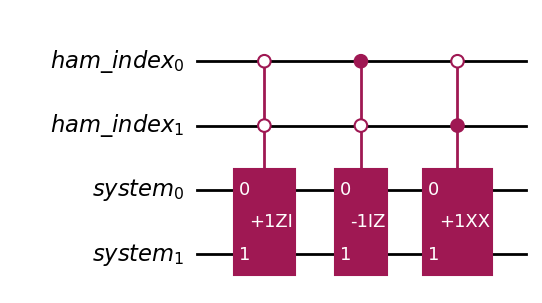

In [39]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Pauli
import numpy as np

# Registers used only to construct SELECT
select_index_register = QuantumRegister(
    num_hamiltonian_index_qubits,
    "ham_index"
)

select_system_register = QuantumRegister(
    num_system_qubits,
    "system"
)

SELECT = QuantumCircuit(
    select_index_register,
    select_system_register,
    name="SELECT"
)

for j, (pauli_string, coefficient) in enumerate(pauli_terms):

    # Extract only the sign of c_j.
    coefficient_sign = 1.0 if coefficient >= 0 else -1.0

    # Matrix representation of the signed Pauli:
    #
    # sign(c_j) P_j
    signed_pauli_matrix = (
        coefficient_sign
        * Pauli(pauli_string).to_matrix()
    )

    signed_pauli_gate = UnitaryGate(
        signed_pauli_matrix,
        label=f"{coefficient_sign:+.0f}{pauli_string}"
    )

    # Apply this signed Pauli only when the Hamiltonian-index
    # register contains the binary representation of j.
    controlled_signed_pauli = signed_pauli_gate.control(
        num_ctrl_qubits=num_hamiltonian_index_qubits,
        ctrl_state=j
    )

    SELECT.append(
        controlled_signed_pauli,
        [
            *select_index_register,
            *select_system_register
        ]
    )

print("SELECT circuit built.")
print("SELECT qubits:", SELECT.num_qubits)
print("SELECT depth:", SELECT.depth())
print("SELECT gate count:", SELECT.count_ops())

SELECT.draw("mpl")

Coherent probability oracle built.
Total qubits: 7
Circuit depth: 8
Gate counts: OrderedDict([('h', 4), ('barrier', 2), ('cccircuit-226_o0', 1), ('cccircuit-233_o1', 1), ('cccircuit-240_o2', 1), ('cccircuit-247', 1), ('PREPARE_G', 1), ('cSELECT', 1), ('PREPARE_G†', 1)])


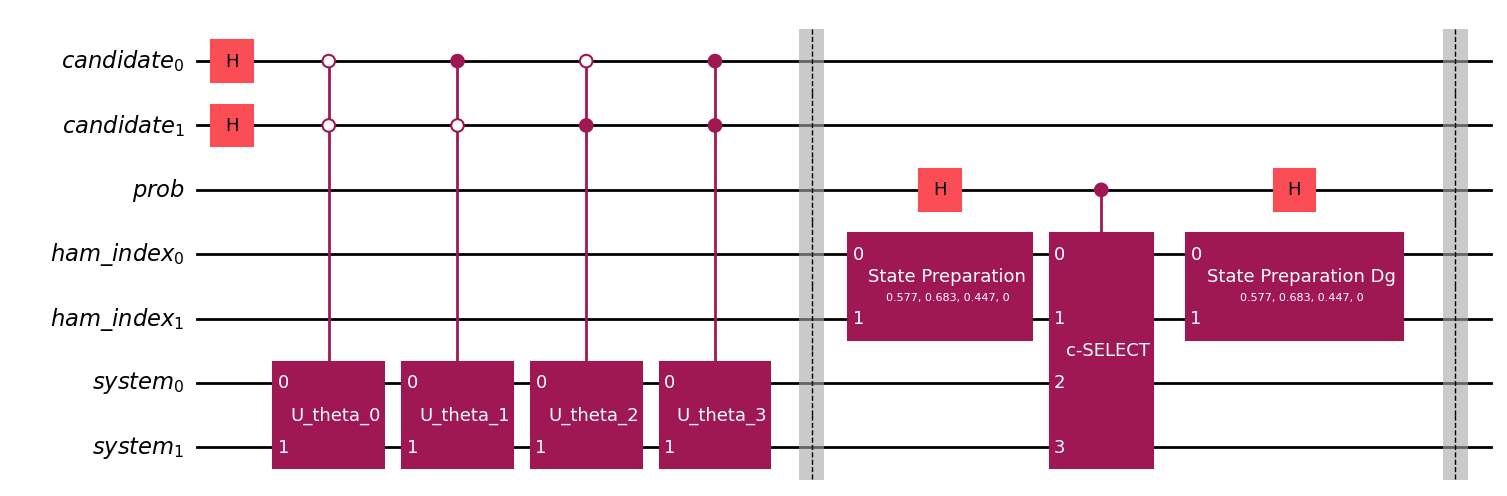

In [40]:
from qiskit import QuantumCircuit, QuantumRegister

# Registers
candidate_register = QuantumRegister(
    num_candidate_qubits,
    "candidate"
)

probability_ancilla = QuantumRegister(
    1,
    "prob"
)

hamiltonian_index_register = QuantumRegister(
    num_hamiltonian_index_qubits,
    "ham_index"
)

system_register = QuantumRegister(
    num_system_qubits,
    "system"
)

coherent_probability_oracle = QuantumCircuit(
    candidate_register,
    probability_ancilla,
    hamiltonian_index_register,
    system_register,
    name="Coherent_Probability_Oracle"
)

# ---------------------------------------------------------
# 1. Prepare:
#
# (1/2) sum_k |k>|psi(theta_k)>
# ---------------------------------------------------------

coherent_probability_oracle.compose(
    coherent_state_loader,
    qubits=[
        *candidate_register,
        *system_register
    ],
    inplace=True
)

coherent_probability_oracle.barrier()

# ---------------------------------------------------------
# 2. Hadamard-test ancilla
# ---------------------------------------------------------

coherent_probability_oracle.h(probability_ancilla[0])

# ---------------------------------------------------------
# 3. Prepare the Hamiltonian coefficient state |G>
# ---------------------------------------------------------

coherent_probability_oracle.append(
    PREPARE_G,
    list(hamiltonian_index_register)
)

# ---------------------------------------------------------
# 4. Apply SELECT only when the probability ancilla is |1>
# ---------------------------------------------------------

controlled_SELECT = SELECT.to_gate(
    label="c-SELECT"
).control(1)

coherent_probability_oracle.append(
    controlled_SELECT,
    [
        probability_ancilla[0],
        *hamiltonian_index_register,
        *system_register
    ]
)

# ---------------------------------------------------------
# 5. Unprepare the Hamiltonian-index register
# ---------------------------------------------------------

coherent_probability_oracle.append(
    PREPARE_G_DAGGER,
    list(hamiltonian_index_register)
)

# ---------------------------------------------------------
# 6. Final Hadamard on the probability ancilla
# ---------------------------------------------------------

coherent_probability_oracle.h(probability_ancilla[0])

coherent_probability_oracle.barrier()

print("Coherent probability oracle built.")
print("Total qubits:", coherent_probability_oracle.num_qubits)
print("Circuit depth:", coherent_probability_oracle.depth())
print("Gate counts:", coherent_probability_oracle.count_ops())

coherent_probability_oracle.draw("mpl", fold=-1)

In [41]:
from qiskit.quantum_info import Statevector, SparsePauliOp
import numpy as np

# Simulate the complete coherent probability-oracle circuit
probability_state = Statevector.from_instruction(
    coherent_probability_oracle
)

# Build the Hamiltonian matrix for the classical reference calculation
H_operator = SparsePauliOp.from_list(pauli_terms)
H_matrix = H_operator.to_matrix()

# Qubit positions in the complete circuit:
#
# candidate_0 -> bit 0
# candidate_1 -> bit 1
# prob        -> bit 2
#
# ham_index and system bits are summed over automatically.
candidate_bit_positions = list(range(num_candidate_qubits))
probability_ancilla_position = num_candidate_qubits

for k, theta_k in enumerate(theta_candidates):

    candidate_branch_probability = 0.0
    joint_candidate_and_prob1 = 0.0

    # Inspect every computational-basis amplitude
    for basis_index, amplitude in enumerate(probability_state.data):

        basis_probability = abs(amplitude) ** 2

        # Extract the candidate-register value from the lowest bits
        candidate_value = basis_index & (
            (1 << num_candidate_qubits) - 1
        )

        if candidate_value == k:

            candidate_branch_probability += basis_probability

            # Extract the probability-ancilla bit
            prob_bit = (
                basis_index >> probability_ancilla_position
            ) & 1

            if prob_bit == 1:
                joint_candidate_and_prob1 += basis_probability

    # Conditional probability:
    #
    # P(prob=1 | candidate=k)
    measured_p_k = (
        joint_candidate_and_prob1
        / candidate_branch_probability
    )

    # Independently prepare |psi(theta_k)>
    reference_circuit = build_candidate_unitary(theta_k)
    reference_state = Statevector.from_instruction(
        reference_circuit
    ).data

    # Classical reference energy
    energy_k = np.real(
        np.vdot(
            reference_state,
            H_matrix @ reference_state
        )
    )

    # Theoretical probability
    expected_p_k = 0.5 * (
        1.0 - energy_k / alpha
    )

    print(f"Candidate k = {k}")
    print(f"  theta_{k} = {theta_k}")
    print(
        f"  candidate branch probability = "
        f"{candidate_branch_probability:.12f}"
    )
    print(f"  energy E_k = {energy_k:.12f}")
    print(f"  oracle probability p_k = {measured_p_k:.12f}")
    print(f"  expected probability  = {expected_p_k:.12f}")
    print(
        f"  absolute error = "
        f"{abs(measured_p_k - expected_p_k):.3e}"
    )
    print()

Candidate k = 0
  theta_0 = [0.12, 0.73, 0.41, 0.88]
  candidate branch probability = 0.250000000000
  energy E_k = -0.496284995417
  oracle probability p_k = 0.665428331806
  expected probability  = 0.665428331806
  absolute error = 1.998e-15

Candidate k = 1
  theta_1 = [0.65, 0.19, 0.94, 0.37]
  candidate branch probability = 0.250000000000
  energy E_k = 0.286048801316
  oracle probability p_k = 0.404650399561
  expected probability  = 0.404650399561
  absolute error = 3.830e-15

Candidate k = 2
  theta_2 = [0.08, 0.56, 0.31, 0.79]
  candidate branch probability = 0.250000000000
  energy E_k = -0.441630610211
  oracle probability p_k = 0.647210203404
  expected probability  = 0.647210203404
  absolute error = 1.221e-15

Candidate k = 3
  theta_3 = [0.44, 0.22, 0.68, 0.15]
  candidate branch probability = 0.250000000000
  energy E_k = 0.131247014593
  oracle probability p_k = 0.456250995136
  expected probability  = 0.456250995136
  absolute error = 2.887e-15

